In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tea340yashjoshi/sepsis-prediction-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/emrecetiner/.cache/kagglehub/datasets/tea340yashjoshi/sepsis-prediction-dataset/versions/1


In [4]:
import os
import pandas as pd

# kagglehub'ın indirdiği klasörün içindeki dosyaları listeleyelim
dosyalar = os.listdir(path)
print("Klasördeki dosyalar:", dosyalar)

# Klasörün içinde muhtemelen 'Dataset.csv' veya benzeri bir .csv dosyası olacak
# Dosya adını yukarıdaki listeden kontrol edip buraya tam adını yazabilirsin
csv_dosya_adi = dosyalar[0] # İlk dosyayı otomatik seçiyoruz
tam_yol = os.path.join(path, csv_dosya_adi)

# Veriyi pandas ile okuyoruz
df_sepsis = pd.read_csv(tam_yol)

# Yoğun bakım zaman serisi yapısını görmek için ilk 20 satıra bakıyoruz
df_sepsis.head(20)

Klasördeki dosyalar: ['Dataset.csv']


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,1.0,0.0,17072.0
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,2.0,0.0,17072.0
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,3.0,0.0,17072.0
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,4.0,0.0,17072.0
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0.0,NaN,NaN,-0.02,5.0,0.0,17072.0
5,5,5,62.0,100.0,NaN,124.0,85.0,61.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,6.0,0.0,17072.0
6,6,6,61.0,100.0,NaN,101.0,75.0,58.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,7.0,0.0,17072.0
7,7,7,68.0,100.0,35.78,142.0,93.5,78.0,16.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,8.0,0.0,17072.0
8,8,8,71.0,100.0,NaN,121.0,74.0,91.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,9.0,0.0,17072.0
9,9,9,69.0,100.0,NaN,120.0,79.0,98.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,10.0,0.0,17072.0


In [5]:
# Her sütunda ne kadar eksik (boş) veri olduğunu yüzdesel olarak görelim
eksik_veri_yuzdesi = (df_sepsis.isnull().sum() / len(df_sepsis)) * 100
print("Sütunların Eksik Veri Yüzdeleri:")
print(eksik_veri_yuzdesi.sort_values(ascending=False))

Sütunların Eksik Veri Yüzdeleri:
EtCO2               100.000000
TroponinI            99.874021
Bilirubin_direct     99.850217
Fibrinogen           99.237534
Bilirubin_total      98.769874
Alkalinephos         98.544284
AST                  98.502352
Lactate              96.578976
PTT                  95.158783
SaO2                 95.114654
Calcium              95.022001
Phosphate            94.945095
Platelets            93.482970
Creatinine           93.369259
WBC                  92.505534
Magnesium            92.237829
HCO3                 91.966096
BUN                  91.860808
Chloride             91.703700
PaCO2                91.290973
Hgb                  91.198320
BaseExcess           89.658374
Potassium            89.194925
pH                   88.613371
Hct                  88.229941
Glucose              87.858413
FiO2                 85.978433
Temp                 66.214388
Unit1                49.698511
Unit2                49.698511
DBP                  47.874197
SBP   

In [6]:
# 1. %90'dan fazla boş olan sütunları tespit edip veri setinden siliyoruz
silinecek_sutunlar = eksik_veri_yuzdesi[eksik_veri_yuzdesi > 90].index
df_temiz_icu = df_sepsis.drop(columns=silinecek_sutunlar)

# 2. Zaman serisi doldurma (Forward Fill): Eksik verileri bir önceki saatteki veriyle doldurur.
# Eğer hastanın geçmiş verisi yoksa, o sütunun genel ortalamasıyla doldurur (bfill).
df_temiz_icu = df_temiz_icu.ffill().bfill()

# 3. Bakalım geriye hangi sütunlar kaldı ve temizlendi mi?
print("Kalan ve tamamen temizlenen sütunlar:")
print(df_temiz_icu.isnull().sum())

Kalan ve tamamen temizlenen sütunlar:
Unnamed: 0     0
Hour           0
HR             0
O2Sat          0
Temp           0
SBP            0
MAP            0
DBP            0
Resp           0
BaseExcess     0
FiO2           0
pH             0
Glucose        0
Potassium      0
Hct            0
Age            0
Gender         0
Unit1          0
Unit2          0
HospAdmTime    0
ICULOS         0
SepsisLabel    0
Patient_ID     0
dtype: int64


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Benzersiz hasta kimliklerini (Patient_ID) buluyoruz
tum_hastalar = df_temiz_icu['Patient_ID'].unique()

# 2. Hastaların %80'ini eğitim, %20'sini test olarak ayırıyoruz
sinir_indeksi = int(len(tum_hastalar) * 0.8)
egitim_hastalari = tum_hastalar[:sinir_indeksi]
test_hastalari = tum_hastalar[sinir_indeksi:]

# 3. Veri setini bu hastalara göre ikiye bölüyoruz
train_data = df_temiz_icu[df_temiz_icu['Patient_ID'].isin(egitim_hastalari)]
test_data = df_temiz_icu[df_temiz_icu['Patient_ID'].isin(test_hastalari)]

# 4. Giriş (X) ve Çıkış (y) değişkenlerini oluşturuyoruz
# 'SepsisLabel' ve kimlik belirten 'Patient_ID', 'Unnamed: 0' gibi sütunları tahmin elamanı yapmıyoruz
silinecekler = ['SepsisLabel', 'Patient_ID', 'Unnamed: 0']
X_train = train_data.drop(columns=silinecekler)
y_train = train_data['SepsisLabel']

X_test = test_data.drop(columns=silinecekler)
y_test = test_data['SepsisLabel']

# 5. Yoğun Bakım Erken Uyarı Yapay Zekasını Eğitiyoruz
icu_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
icu_model.fit(X_train, y_train)

# 6. Test Hastaları Üzerinde Tahmin Yapıyoruz
tahminler = icu_model.predict(X_test)

# 7. Sonuçları Rapora Döküyoruz
print(f"Yoğun Bakım Model Başarı Oranı: %{accuracy_score(y_test, tahminler) * 100:.2f}\n")
print(classification_report(y_test, tahminler))

Yoğun Bakım Model Başarı Oranı: %97.67

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99    107778
         1.0       0.17      0.01      0.01      2498

    accuracy                           0.98    110276
   macro avg       0.57      0.50      0.50    110276
weighted avg       0.96      0.98      0.97    110276



In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report

# 1. Veriyi LightGBM'in anlayacağı özel bir formata getiriyoruz
train_data_lgb = lgb.Dataset(X_train, label=y_train)

# 2. Model parametrelerini ayarlıyoruz
# 'is_unbalance': True ayarı modelin azınlıktaki Sepsis vakalarına odaklanmasını sağlar
parametreler = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'is_unbalance': True,  
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'verbose': -1,
    'random_state': 42
}

# 3. Modeli eğitiyoruz
print("Gelişmiş LightGBM modeli eğitiliyor...")
lgb_model = lgb.train(parametreler, train_data_lgb, num_boost_round=150)

# 4. Test hastaları üzerinde tahmin yapıyoruz
# LightGBM olasılık döndürür (0 ile 1 arasında), 0.5'ten büyükse 1 (Sepsis) kabul ediyoruz
olasiliklar = lgb_model.predict(X_test)
tahminler_lgb = [1 if x >= 0.5 else 0 for x in olasiliklar]

# 5. Yeni raporu yazdıralım
print("\n--- Gelişmiş Yoğun Bakım Yapay Zeka Sonuçları ---")
print(classification_report(y_test, tahminler_lgb))

Gelişmiş LightGBM modeli eğitiliyor...

--- Gelişmiş Yoğun Bakım Yapay Zeka Sonuçları ---
              precision    recall  f1-score   support

         0.0       0.99      0.85      0.91    107778
         1.0       0.08      0.56      0.14      2498

    accuracy                           0.84    110276
   macro avg       0.53      0.70      0.52    110276
weighted avg       0.97      0.84      0.89    110276



In [10]:
import matplotlib.pyplot as plt
import numpy as np

# LightGBM özellik önem sırasını alıyoruz
onem_dereceleri = lgb_model.feature_importance(importance_type='gain')
ozellik_isimleri = X_train.columns

# Sıralama yapalım
indeksler = np.argsort(onem_dereceleri)[::-1]

print("--- Yapay Zekanın Sepsis Tespit Ederken En Çok Baktığı Tıbbi Bulgular ---")
for i in range(len(ozellik_isimleri)):
    print(f"{i+1}. {ozellik_isimleri[indeksler[i]]}: {onem_dereceleri[indeksler[i]]:.2f}")

Matplotlib is building the font cache; this may take a moment.


--- Yapay Zekanın Sepsis Tespit Ederken En Çok Baktığı Tıbbi Bulgular ---
1. ICULOS: 2110902.82
2. HospAdmTime: 639882.81
3. Age: 527167.95
4. Temp: 448715.65
5. Hct: 334817.31
6. Glucose: 328663.90
7. HR: 195757.92
8. FiO2: 191891.86
9. BaseExcess: 183377.21
10. pH: 183110.93
11. Potassium: 168255.44
12. DBP: 162353.21
13. Resp: 124183.94
14. SBP: 108515.76
15. Hour: 96629.33
16. Unit1: 78552.94
17. Gender: 44827.20
18. O2Sat: 38523.70
19. MAP: 34452.33
20. Unit2: 0.00


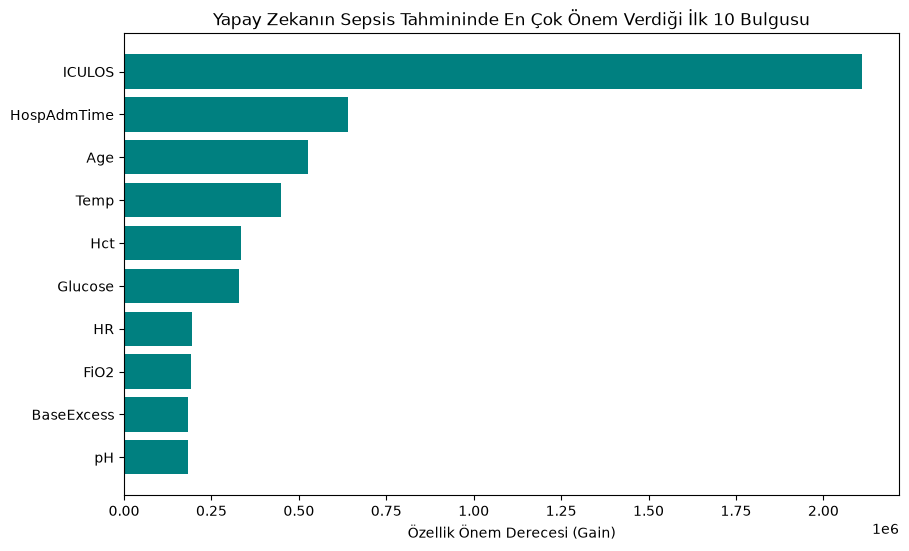

In [11]:
# Grafiğin boyutunu ayarlayalım
plt.figure(figsize=(10, 6))

# En önemli ilk 10 özelliği görselleştirelim
en_onemli_indeksler = indeksler[:10]

plt.barh(range(10), onem_dereceleri[en_onemli_indeksler], align='center', color='teal')
plt.yticks(range(10), [ozellik_isimleri[i] for i in en_onemli_indeksler])
plt.xlabel('Özellik Önem Derecesi (Gain)')
plt.title('Yapay Zekanın Sepsis Tahmininde En Çok Önem Verdiği İlk 10 Bulgusu')
plt.gca().invert_yaxis()  # En önemli olanı en üstte göstermek için ters çeviriyoruz
plt.show()